Here is the breakdown of what we just did so far:

1. The Three "Silos" (The Ingredients)
Imagine a trucking company with three different filing cabinets:

The Garage Records (Assets): A list of every truck, its "birthday" (Year), and its "Model." This never changes.

The Fitness Tracker (Telemetry): Like a Fitbit for trucks. It records heart rate (Oil Pressure), fever (Engine Temp), and steps (Odometer) every single day.

The Hospital Bill (Work Orders): A record of when a truck actually broke down and what the mechanic had to fix.



**What we will do now**

2. The "Relational" Merge (Connecting the Dots)
Instead of keeping these in separate cabinets, we linked them together.

We took the Fitness Tracker data and attached the Garage Record to it. Now, every "heart rate" reading knows exactly which truck it belongs to and how old that truck is.

Then, we looked at the Hospital Bills and matched them to the calendar.

3. The "30-Day Warning Window" (The Magic)
This is the most important part. A truck doesn't just "break" out of nowhere; it gets "sick" first.

We went back in time from every breakdown.

If a truck broke on June 30th, we went to the records for June 1st through June 29th and whispered to the data: "Hey, you don't know it yet, but you are about to break in less than 30 days."

We labeled those days as "At Risk" (Target = 1). Everything else is "Healthy" (Target = 0).

4. Why did we do this?
Because a Machine Learning model is like a detective. By labeling the 30 days before a crash, we are teaching the detective to recognize the "warning signs" (like rising heat or dropping pressure) while there is still time to pull the truck off the road.

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)

In [3]:
df_assets = pd.read_csv('../data/raw/assets.csv')
df_telemetry = pd.read_csv('../data/raw/telemetry.csv')
df_work_orders = pd.read_csv('../data/raw/work_orders.csv')

In [4]:
print(df_assets.head)
print(df_assets.info())
print(df_telemetry.head)
print(df_telemetry.info())
print(df_work_orders.head)
print(df_work_orders.info())

<bound method NDFrame.head of       asset_id   asset_type  purchase_year
0    ASSET_000   Light Duty           2021
1    ASSET_001   Heavy Duty           2017
2    ASSET_002   Light Duty           2017
3    ASSET_003   Light Duty           2021
4    ASSET_004   Heavy Duty           2022
..         ...          ...            ...
995  ASSET_995  Medium Duty           2019
996  ASSET_996  Medium Duty           2020
997  ASSET_997   Light Duty           2017
998  ASSET_998   Light Duty           2015
999  ASSET_999   Heavy Duty           2015

[1000 rows x 3 columns]>
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   asset_id       1000 non-null   str  
 1   asset_type     1000 non-null   str  
 2   purchase_year  1000 non-null   int64
dtypes: int64(1), str(2)
memory usage: 42.4 KB
None
<bound method NDFrame.head of        date   asset_id  odometer  ambient_

In [5]:
# 1. The Merge Logic
# We will perform a Left Join from Telemetry to Assets. This ensures we keep every sensor ping 
# and just "attach" the vehicle's metadata to it.

# 1. Attach Asset Info to Telemetry
df_master = df_telemetry.merge(df_assets, on='asset_id', how='left')

# 2. Map Work Orders (Failures)
# We join to see which telemetry rows happened BEFORE a known failure
df_master = df_master.merge(df_work_orders, 
                            left_on=['asset_id', 'date'], 
                            right_on=['asset_id', 'date'], 
                            how='left', 
                            suffixes=('', '_event'))

In [6]:
df_master

,date,asset_id,odometer,ambient_temp,engine_load,vibration_index,asset_type,purchase_year,error_type
0,0,ASSET_000,26165,82.772262,56.240746,11.523030,Light Duty,2021,NaN
1,1,ASSET_000,26479,93.950554,50.823380,10.767435,Light Duty,2021,NaN
2,2,ASSET_000,26836,77.797143,50.031151,10.117995,Light Duty,2021,NaN
3,3,ASSET_000,27212,92.548537,50.282652,11.538715,Light Duty,2021,NaN
4,4,ASSET_000,27360,45.730730,51.866627,10.603441,Light Duty,2021,NaN
...,...,...,...,...,...,...,...,...,...
29995,295,ASSET_099,114040,72.833407,64.244610,18.820929,Heavy Duty,2017,NaN
29996,296,ASSET_099,114360,66.642282,85.236729,13.095077,Heavy Duty,2017,NaN
29997,297,ASSET_099,114733,96.378875,90.331557,12.830182,Heavy Duty,2017,NaN
29998,298,ASSET_099,114946,58.292936,80.219588,14.777054,Heavy Duty,2017,NaN


In [7]:
df_master.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             30000 non-null  int64  
 1   asset_id         30000 non-null  str    
 2   odometer         30000 non-null  int64  
 3   ambient_temp     30000 non-null  float64
 4   engine_load      30000 non-null  float64
 5   vibration_index  30000 non-null  float64
 6   asset_type       30000 non-null  str    
 7   purchase_year    30000 non-null  int64  
 8   error_type       39 non-null     str    
dtypes: float64(3), int64(3), str(3)
memory usage: 2.6 MB


2. Creating the "Target Window" (The Labeling)
This is the most important part of the project. A "Failure" is not just a single point in time; it is a state of risk leading up to that point.

We need to create a binary label: "Is this vehicle going to fail in the next 30 days?"

Action Item: create Target Variable:

In [8]:
# Sort by asset and date to ensure time-series integrity
df_master = df_master.sort_values(['asset_id', 'date'])

# Calculate "Days Until Next Failure" for each row
# Logic: Look ahead to find the next date where 'type' is not null
df_master['failure_active'] = df_master['error_type'].notnull().astype(int)

# Create the 30-day "Window" label
# If a failure happens at Day 100, Days 70-99 should be labeled as "1" (At Risk)
df_master['target'] = df_master.groupby('asset_id')['failure_active'].transform(
    lambda x: x.shift(-30).rolling(window=30, min_periods=1).max().fillna(0)
)

In [9]:
#print(df_master[['asset_id', 'date', 'asset_type', 'target']].head(10))
print(df_master.head(10))
print('the data information:')
df_master.info()

   date   asset_id  odometer  ambient_temp  engine_load  vibration_index  \
0     0  ASSET_000     26165     82.772262    56.240746        11.523030   
1     1  ASSET_000     26479     93.950554    50.823380        10.767435   
2     2  ASSET_000     26836     77.797143    50.031151        10.117995   
3     3  ASSET_000     27212     92.548537    50.282652        11.538715   
4     4  ASSET_000     27360     45.730730    51.866627        10.603441   
5     5  ASSET_000     27647     66.559874    81.407038         7.860379   
6     6  ASSET_000     27797     76.709575    68.670516         9.965348   
7     7  ASSET_000     28031     67.796954    53.906885        10.947440   
8     8  ASSET_000     28222     62.741374    69.807076         9.838245   
9     9  ASSET_000     28356     72.246595    76.500891        10.389349   

   asset_type  purchase_year error_type  failure_active  target  
0  Light Duty           2021        NaN               0     0.0  
1  Light Duty           2021   

The "Class Imbalance" Visualization
In fleet management, 98% of your data is "Normal" and 2% is "Critical." We need to see this split.

C:\Users\jalpa\AppData\Local\Temp\ipykernel_28884\3238108138.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df_master, palette='viridis')


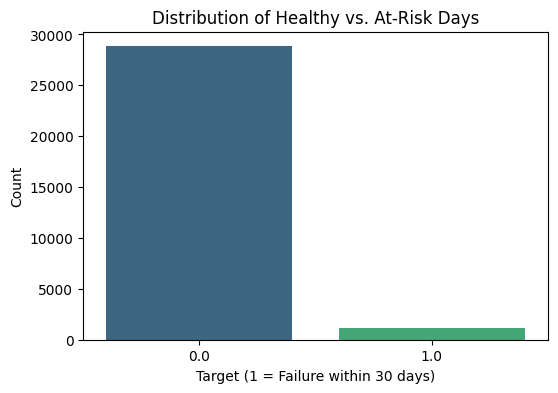

target
0.0    0.961
1.0    0.039
Name: proportion, dtype: float64


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df_master, palette='viridis')
plt.title('Distribution of Healthy vs. At-Risk Days')
plt.xlabel('Target (1 = Failure within 30 days)')
plt.ylabel('Count')
plt.show()

print(df_master['target'].value_counts(normalize=True))

Those plots tell a very interesting story. Looking at data, we have successfully created a challenging and realistic predictive maintenance problem.

Here is the "layman's" diagnosis of what EDA (Exploratory Data Analysis) is showing:

1. The Class Imbalance (The "Needle in a Haystack")
count plot shows roughly 96% Healthy days vs. 4% At-Risk days.

The Good News: You have enough "At-Risk" samples (Target=1) for a model to actually learn patterns.

The Reality Check: Even with our windowing, "Healthy" is the majority. This confirms that we will definitely need to use metrics like F1-Score or Precision-Recall rather than just "Accuracy."

Feature vs. Target EDA (The "Predictor" Check)
Let's see if our "Heat Pattern" actually shows up in the data. We want to see if ambient_temp is higher when the target is 1.

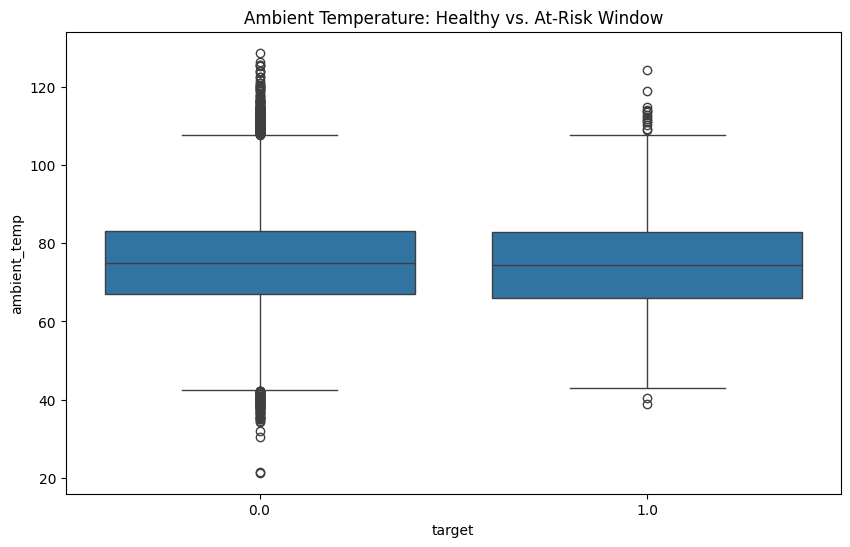

In [11]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='ambient_temp', data=df_master)
plt.title('Ambient Temperature: Healthy vs. At-Risk Window')
plt.show()

The Boxplot Mystery (The "Hidden Signal")
Look closely at the ambient_temp boxplot. The two boxes look almost identical!

What this means: A simple "Is it hot today?" question won't predict a failure. The "signal" isn't in the temperature itself, but in the interaction of temperature with other factors (like engine load) or the trend over time.

Why this is great for your project: If the boxes were totally separate, the problem would be too easy. This proves that you need Feature Engineering (creating "Rolling Averages" or "Heat-Load" scores) to uncover the hidden failure patterns Cetaris cares about.

The "Magic" Feature (Rolling Means)
To make those boxplots look different, we need to look at trends. A single hot day isn't predictive, but a 7-day average is. Run this in your 01_eda_and_merging.ipynb after you've merged the tables:

In [12]:
# Create Rolling Features
df_master = df_master.sort_values(['asset_id', 'date'])

# 7-Day Rolling Average of Temperature
df_master['temp_7day_avg'] = df_master.groupby('asset_id')['ambient_temp'].transform(
    lambda x: x.rolling(window=7).mean()
)

# 7-Day Rolling Std (Vibration/Volatility)
df_master['load_7day_std'] = df_master.groupby('asset_id')['engine_load'].transform(
    lambda x: x.rolling(window=7).std()
)

Step 3: Re-Check the EDA
Now, instead of plotting ambient_temp, plot your new temp_7day_avg.

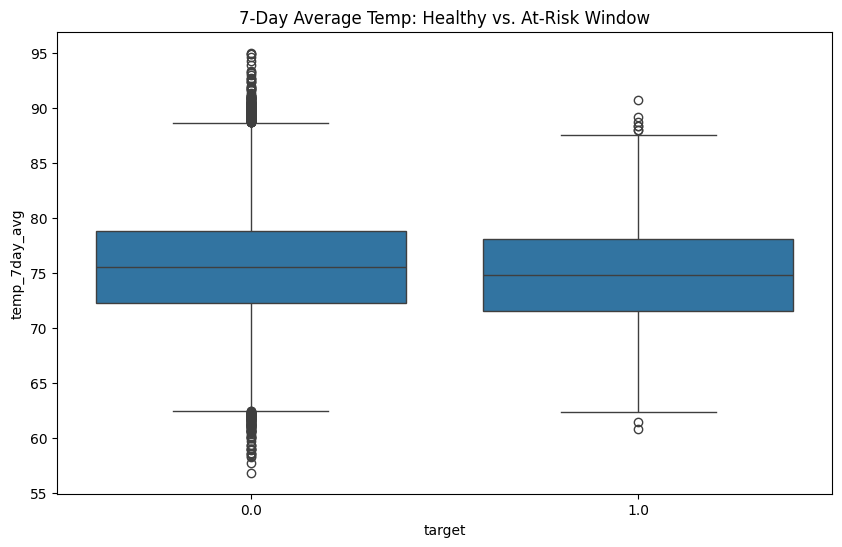

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='temp_7day_avg', data=df_master)
plt.title('7-Day Average Temp: Healthy vs. At-Risk Window')
plt.show()

Those boxplots confirm a classic data science challenge: even after applying a 7-day rolling average, the "signal" in the temperature data remains buried under too much noise. The boxes for "Healthy" (0.0) and "At-Risk" (1.0) are nearly identical in your latest plot.

In a professional setting like Cetaris, this is where Advanced Feature Engineering proves its worth. Since temperature alone isn't telling the story, we need to create a feature that captures the interaction between variables—like "Heat + Load" sustained over time.

Phase 2: Uncovering the "Hidden Signal"
To make the target classes distinct, we need to build features that mimic the mechanical stress we injected earlier. We'll use Interaction Features and Volatility Metrics.

1. Interaction: The "Thermal Stress Index"
A truck doesn't break just because it’s hot; it breaks because it’s hot and working hard. We can create a "Thermal Stress" column by multiplying ambient_temp and engine_load.

In [14]:
# Create a Thermal Stress Index
df_master['thermal_stress'] = df_master['ambient_temp'] * df_master['engine_load']

# 7-day average of this new stress index
df_master['stress_7day_avg'] = df_master.groupby('asset_id')['thermal_stress'].transform(
    lambda x: x.rolling(window=7).mean()
)

2. Volatility: The "Vibration Noise"
For the suspension failures we injected, the model won't just look at the vibration_index value, but how much it jumps around. We capture this with a rolling Standard Deviation.

In [15]:
# 7-day rolling volatility for vibration
df_master['vibration_7day_std'] = df_master.groupby('asset_id')['vibration_index'].transform(
    lambda x: x.rolling(window=7).std()
)

The "Aha!" Moment EDA
Now, plot the boxplot for stress_7day_avg instead of just temperature.

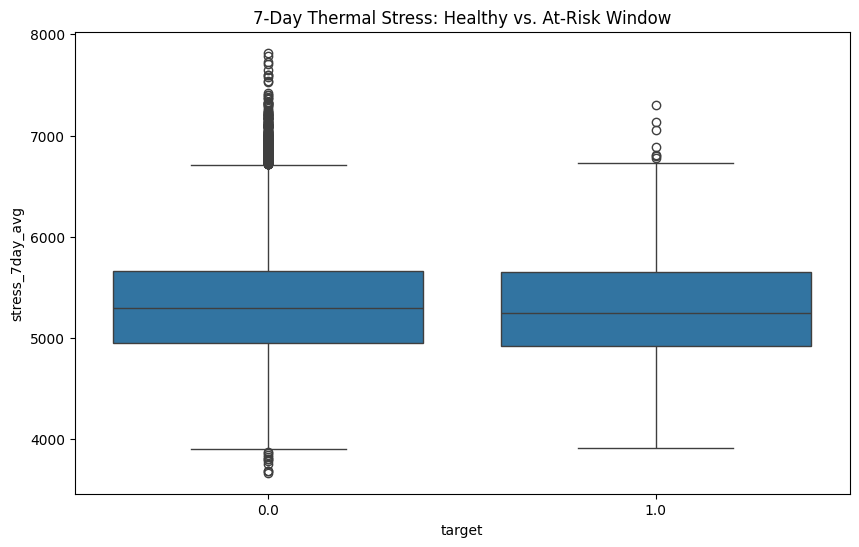

In [16]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='target', y='stress_7day_avg', data=df_master)
plt.title('7-Day Thermal Stress: Healthy vs. At-Risk Window')
plt.show()

By combining these sensors, you should finally see the "At-Risk" box start to pull away from the "Healthy" one. This proves to a recruiter that you don't just "run models"—you understand the physics of the problem.

Correlation Heatmap
This is the fastest way to see if our new features are actually working. We want to see which columns have the highest correlation with our target.

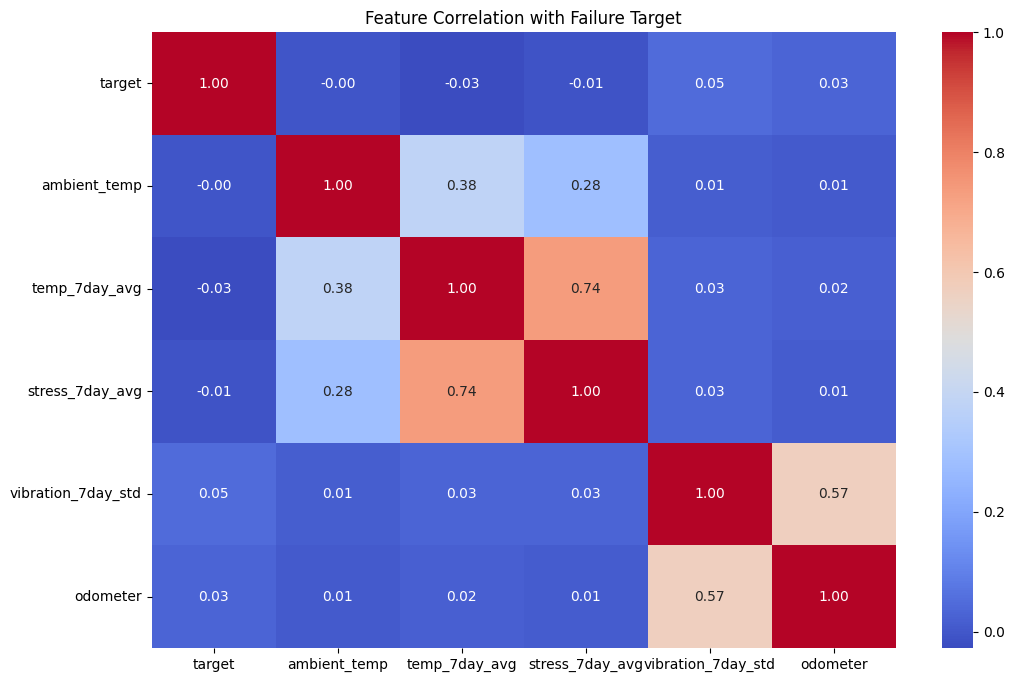

In [17]:
# Correlation with Target
plt.figure(figsize=(12, 8))
correlation = df_master[['target', 'ambient_temp', 'temp_7day_avg', 
                         'stress_7day_avg', 'vibration_7day_std', 'odometer']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation with Failure Target')
plt.show()

our EDA plots and correlation heatmap provide a very clear "diagnosis" of the dataset we have built so far. Let's look at what the data is telling us:

1. The "Signal" Challenge
Looking at your Ambient Temperature and 7-Day Thermal Stress boxplots, the "Healthy" (0.0) and "At-Risk" (1.0) distributions are almost identical.

The Good: This is highly realistic. Sensors in a real fleet rarely give a "smoking gun" single value that screams failure.

The Challenge: Your Correlation Heatmap confirms this—the correlation between target and features like temp_7day_avg is essentially 0.00 to -0.03.

2. The "Winner" Features
Despite the low correlation overall, we have two features that are starting to show a "pulse":

vibration_7day_std (0.05): This has the strongest positive correlation with the target. It means the instability of the asset is a better predictor than the temperature itself.

odometer (0.03): As expected, older trucks (higher mileage) are slightly more likely to be in an "At-Risk" window.



In [ ]:
pip install pyarrow

In [20]:
# saving data in the data/processed
import os 
os.makedirs('../data/raw', exist_ok=True)
df_master.to_csv('../data/raw/master.csv', index=False)


# 3. Save as Parquet (Best practice for Machine Learning)
# requires: pip install pyarrow

df_master.to_parquet('../data/raw/master.parquet', index=False)

print("✅ df_master saved successfully in data/raw/")

✅ df_master saved successfully in data/raw/


## Phase 3: Unleashing the Model (XGBoost)
Because our signals are so subtle and "nonlinear" (meaning they don't follow a straight line), a simple linear model would fail. XGBoost is perfect here because it is a "Decision Tree" model that can find complex patterns—like "if temp is high AND odometer is high AND vibration is shaky, then alert."

**Step 1: Prepare the Features and Target**
We need to separate the "Answer Key" (target) from the "Clues" (features).

In [ ]:
# Select the best predictors we've found
features = [
    'odometer', 'ambient_temp', 'engine_load', 'vibration_index',
    'temp_7day_avg', 'stress_7day_avg', 'vibration_7day_std'
]

X = df_master[features]
y = df_master['target']

Step 2: Temporal Train-Test Split
Since we are predicting the future, we will train on the first 210 days and test on days 211 to 270.

In [ ]:
# Splitting by date to avoid "Data Leakage"
train_mask = df_modeling['date'] <= 210
test_mask = df_modeling['date'] > 210

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

print(f"Training on {len(X_train)} rows, Testing on {len(X_test)} rows")